# Processing of the statistics gathered during the runs on the cluster

In [1]:
import glob
import pandas as pd
%matplotlib inline

In [2]:
date = r'20180612'
path = r'../results/' + date + r'/'
allFiles = glob.glob(path + "*.csv")
allStatsCSV = r'allStats.csv'
df = pd.DataFrame()
list_ = []
for file_ in allFiles:
    if str(file_) != (path + allStatsCSV):
        df = pd.read_csv(file_, index_col=None, header=0)
        columns = df.columns.tolist()
        cols_to_use = columns[:len(columns) - 1] # drop the last one
        df = df[cols_to_use]
        list_.append(df)
df = pd.concat(list_)
df['inputFileName'] = df['inputFileName'].str.slice(len('/data/datasets/'))

In [3]:
allStats = df[['inputFileName', 'summaryType', 'allTriplesSummarizationTime', 'outputGraphSize']].sort_values(['summaryType', 'inputFileName'])
allStats = allStats.pivot(index='inputFileName', columns='summaryType', values='outputGraphSize')
allStats.to_csv(path + allStatsCSV)

In [4]:
allStats

summaryType,nan,1fb,2ps,2pts,2ptw,2pw,s,ts,tw,w
inputFileName,,,,,,,,,,
bsbm/bsbm100m.nt,NaN,37805.0,13429.0,40270.0,40270.0,13390.0,NaN,40270.0,40270.0,13390.0
bsbm/bsbm10m.nt,NaN,11424.0,4101.0,14813.0,14813.0,4066.0,4102.0,14813.0,14813.0,4066.0
bsbm/bsbm1m.nt,NaN,4731.0,1067.0,3054.0,3054.0,1046.0,1067.0,3054.0,3054.0,1046.0
dblp/dblp_large.nt,217.0,8899.0,95.0,221.0,221.0,45.0,NaN,NaN,221.0,45.0
dbpedia/dbpedia_persondata_en.nt,NaN,1817.0,23.0,12.0,12.0,10.0,21.0,12.0,12.0,10.0
insee/insee_geo.nt,NaN,632.0,752.0,799.0,798.0,738.0,752.0,799.0,798.0,738.0
lubm/lubm100m.nt,NaN,243.0,72.0,143.0,143.0,38.0,72.0,143.0,143.0,38.0
lubm/lubm10m.nt,NaN,239.0,72.0,143.0,143.0,38.0,72.0,143.0,143.0,38.0
lubm/lubm1m.nt,NaN,263.0,71.0,143.0,143.0,38.0,71.0,143.0,143.0,38.0


In [5]:
def number(summaryType):
    if summaryType == 'w':
        return 0.1
    elif summaryType == 's':
        return 0.2
    elif summaryType == 'tw':
        return 0.3
    elif summaryType == 'ts':
        return 0.4
    elif summaryType == '2pw':
        return 0.5
    elif summaryType == '2ps':
        return 0.6
    elif summaryType == '2ptw':
        return 0.7
    elif summaryType == '2pts':
        return 0.8
    elif summaryType == '1fb':
        return 0.9
    return 0

df['color'] = df.apply(lambda row: number(row['summaryType']), axis=1)

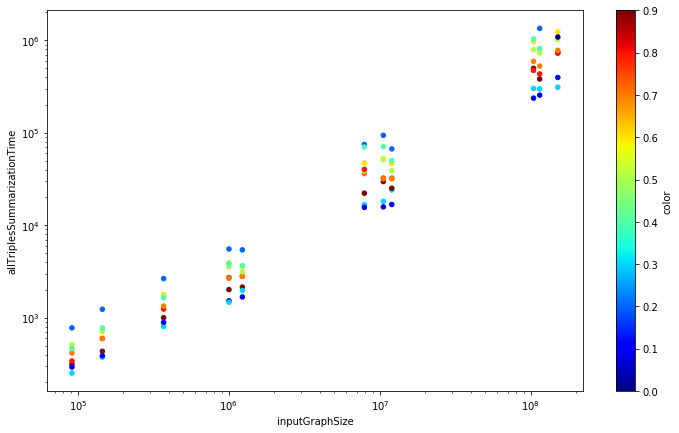

In [6]:
df[['allTriplesSummarizationTime', 'inputGraphSize', 'summaryType', 'inputFileName', 'color']].plot.scatter(x='inputGraphSize', logx=True, y='allTriplesSummarizationTime', logy=True, c='color', colormap='jet', figsize=(12, 7), sharex=False)

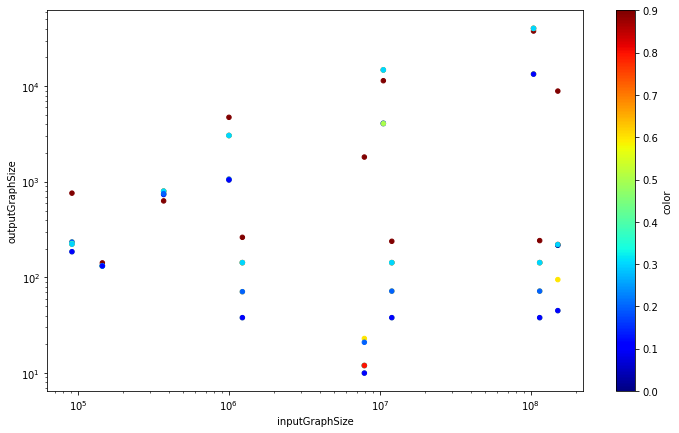

In [7]:
df[['outputGraphSize', 'inputGraphSize', 'summaryType', 'inputFileName', 'color']].plot.scatter(x='inputGraphSize', logx=True, y='outputGraphSize', logy=True, c='color', colormap='jet', figsize=(12, 7), sharex=False)